In [221]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [222]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train/255
X_test = X_test/255
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

# Lab 9
### Model 3 Optimization
Today, we have an exciting lab ahead. Your task is to enhance our model by reducing the number of errors. Let's create a new version, Model 3, and experiment with various parameters.
 
Consider 
* adjusting the number of **epochs**,
* exploring different **activation functions**, and 
* modifying the **hidden layers**, 
* among other options.
While we already have a good test score, don’t expect dramatic improvements, but aim to optimize the model further.

In [223]:
model3 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(200, input_shape=(784,), activation='relu'),
        tf.keras.layers.Dense(100, activation='sigmoid'),
        tf.keras.layers.Dense(10, activation='softplus')
    ]
)

model3.compile(
    optimizer = 'rmsprop',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model3.fit(X_train_flattened, y_train, epochs=25)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8620 - loss: 0.5624
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9670 - loss: 0.1114
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9778 - loss: 0.0731
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9834 - loss: 0.0567
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9873 - loss: 0.0442
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9898 - loss: 0.0336
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9919 - loss: 0.0263
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9941 - loss: 0.0216
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9937 - loss: 0.0205
Epoch 10/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9960 - loss: 0.0148
Epoch 11/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9968 - loss: 0.0116
Epoch 12/25
1875/1875 ━━━━━━━━

In [224]:
y_predicted3 = model3.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [225]:

y_predicted_labels3 = [int(np.argmax(y_pred)) for y_pred in y_predicted3]

In [226]:
errors3 = (y_predicted_labels3 - y_test)
y_errors_indexes3 = [i for i, error in enumerate(errors3) if error]
len(y_errors_indexes3)

171

# Errors
**Epochs** - 
5: 228 - 10: 214 - 15: 195 - 25: 186 - 35: 199
## => Epochs = 25
**Activation functions** - 
Hidden layer - ReLU: 186 - Sigmoid: 206 - Tanh: 236 - Softmax: 577 - Softplus: 189
## => Activation Function Hidden Layer = ReLU
Output layer - ReLU: 9020 - Sigmoid: 229 - Tanh: 8257 - Softmax: 226 - Softplus: 215
## => Activation Function Output Layer = SoftPlus
**Adding second hidden layer**
error: 178
## Add second hidden layer
**different optimizers**
SGD: 236 - Adam: 178 - RMSprop: 165 - Adagrad: 603 - Adadelta: 1125 - FTRL: 8865 - Nadam: 191 - 
## => optimizer = RMSprop
**Adding third hidden layer**
error: 191
## No third hidden layer
Second hidden layer - ReLU: 165 - Sigmoid: 163 - Tanh: 171 - Softmax: 425 - Softplus: 185
## => Activation Function Second Hidden Layer = Sigmoid

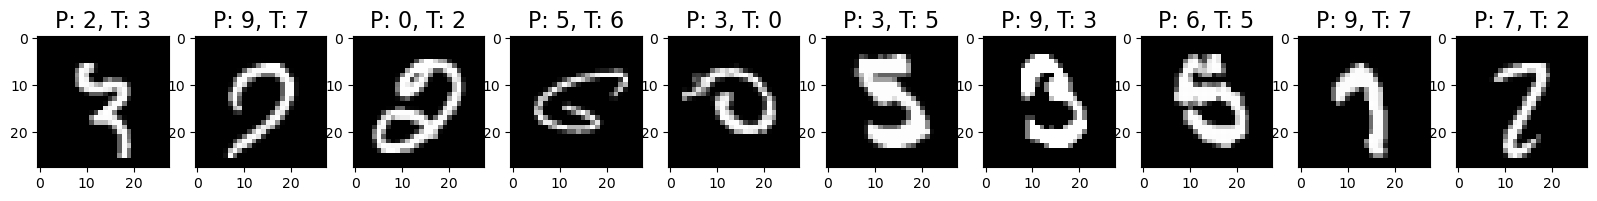

In [227]:
import random

idx_to_check = [y_errors_indexes3[random.randint(0, len(y_errors_indexes3)-1)] for _ in range(10)]

num_classes = 10

_, ax = plt.subplots(1, num_classes, figsize = (20,20))
for i, idx in enumerate(idx_to_check):
    sample = X_test[idx]
    predicted_value = y_predicted_labels3[idx]
    true_value = y_test[idx]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'P: {predicted_value}, T: {true_value}', fontsize=16)
